# Exploratory Notebook

## Basic imports

In [138]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from plotting_utils import FlatmapMapper, FigureConfig, FlatmapPlotter

from pathlib import Path

sys.path.append('../')
from data_loading import (
    DataSequence, ContextManager, EmbeddingManager, 
    file_io, config, prepare_data, preprocessing
)

from main import pipeline

root_dir = Path('../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
import itertools

def pos_combinations(pos):
    pos_permutation = []

    for r in range(1, len(pos) + 1):
        # itertools.combinations(iterable, length) - no repetition
        for p in itertools.combinations(pos, r):
            pos_permutation.append(list(p))
    
    pos_permutation = ['remove-pos-' + '-'.join(x) for x in pos_permutation]
    return pos_permutation


In [122]:
def get_significant_voxels(results, mode):
    sig = np.array(results[mode]['r'])
    sig[results[mode]['fdr']['r']['excluded_voxels_indices']] = np.nan
    return sig

In [123]:
from plotting_utils import SingleCorrelationStrategy
subject = "subject07"
modality = "listening"
mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
fig_config = FigureConfig(
    figsize=(12, 8), 
    save=True, 
    smooth=True, 
    show=False,
    show_regions=True,
    output_dir=root_dir/config.OUTPUT_DIR/"images"/modality/"heatmaps",
)
plotter = FlatmapPlotter(mapper, fig_config)
title = "{title}\nSubject: {subject} | Modality: {modality}"
modes = config.MODES

## Generate Results (All Modes)

In [114]:
subject = 'subject07'
modality = 'listening'
#modes = ['english1000', 'baseline', 'remove-valleys', 'remove-peaks', 'zero', 'random', 'shuffle']
pos = ['noun', 'verb', 'adj', 'adv', 'pron', 'intj']
#modes = modes + pos_combinations(pos)
modes = [f'remove-pos-pct-{p}' for p in pos]

In [115]:
for mode in modes:
    print("="*60)
    print(f"Processing mode: {mode}")
    print("-"*60)
    try:
        pipeline(
            [subject],
            modality,
            mode,
            config.STORIES,
            config.NUIS_LISTENING,
            config.NUIS_READING,
            root_dir
        )
    except Exception as e:
        print(f"Error processing mode {mode}: {e}")

Processing mode: remove-pos-pct-noun
------------------------------------------------------------


Generating POS-percentage-based masks for story: alternateithicatom_en: 100%|██████████| 2175/2175 [00:08<00:00, 244.61it/s]
Generating POS-percentage-based masks for story: avatar_en: 100%|██████████| 1464/1464 [00:05<00:00, 258.71it/s]
Generating POS-percentage-based masks for story: howtodraw_en: 100%|██████████| 1965/1965 [00:07<00:00, 258.90it/s]
Generating POS-percentage-based masks for story: legacy_en: 100%|██████████| 1892/1892 [00:07<00:00, 260.40it/s]
Generating POS-percentage-based masks for story: life_en: 100%|██████████| 2210/2210 [00:08<00:00, 260.36it/s]
Generating POS-percentage-based masks for story: myfirstdaywiththeyankees_en: 100%|██████████| 2787/2787 [00:10<00:00, 253.64it/s]
Generating POS-percentage-based masks for story: naked_en: 100%|██████████| 3220/3220 [00:12<00:00, 260.22it/s]
Generating POS-percentage-based masks for story: odetostepfather_en: 100%|██████████| 2671/2671 [00:10<00:00, 256.00it/s]
Generating POS-percentage-based masks for story: souls_en

Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/scripts/../data_loading/__init__.py:173: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = {subject: zscore(R_val[subject][stories_val[0]].mean(0)[:-5]) for subject in R_val.keys()}


 ✓
Building feature groups... ✓
Performing Group Ridge CV for subject07
------------------------------------------------------------
Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 256.95 sec | 100 random sampling with cv | 
Model fitting complete.
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Performing permutation tests...

...

Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Doing lanczos interpolation with cutoff=0.499 and 3 lobes.
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/scripts/../data_loading/__init__.py:173: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = {subject: zscore(R_val[subject][stories_val[0]].mean(0)[:-5]) for subject in R_val.keys()}


 ✓
Building feature groups... ✓
Performing Group Ridge CV for subject07
------------------------------------------------------------
Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 247.66 sec | 100 random sampling with cv | 
Model fitting complete.
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Performing permutation tests...

100%|██████████| 2500/2500 [00:52<00:00, 47.84it/s]


 ✓
Applying FDR correction... ✓
Saved results to /mnt/antares_raid/home/simonee/nonsense/outputs/results/listening/subject07.npy
Error saving results for subject07: plot_correlation_on_flatmap() takes from 6 to 9 positional arguments but 10 were given
Averaged correlation (r) across voxels: 0.2172795981168747
Script execution finished.


## Generate Single Result

In [127]:
subject = 'subject07'
modality = 'listening'
mode = 'remove-pos-pct-verb'

In [128]:
pipeline(
    [subject],
    modality,
    mode,
    config.STORIES,
    config.NUIS_LISTENING,
    config.NUIS_READING,
    root_dir
)

Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/scripts/../data_loading/__init__.py:173: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = {subject: zscore(R_val[subject][stories_val[0]].mean(0)[:-5]) for subject in R_val.keys()}


 ✓
Building feature groups... ✓
Performing Group Ridge CV for subject07
------------------------------------------------------------
Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 254.22 sec | 100 random sampling with cv | 
Model fitting complete.
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Performing permutation tests...

100%|██████████| 2500/2500 [00:52<00:00, 47.58it/s]


 ✓
Applying FDR correction... ✓
Saved results to /mnt/antares_raid/home/simonee/nonsense/outputs/results/listening/subject07.npy
Error saving results for subject07: plot_correlation_on_flatmap() takes from 6 to 9 positional arguments but 10 were given
Averaged correlation (r) across voxels: 0.21797332167625427
Script execution finished.


{'r': array([           nan,            nan,            nan, ...,
        -1.0668497e-08, -8.0000907e-03,  2.3813114e-02],
       shape=(92970,), dtype=float32),
 'r2': array([           nan,            nan,            nan, ...,
        -3.2687499e-11, -7.3610590e-04,  4.4685162e-08],
       shape=(92970,), dtype=float32),
 'pvalues': {'r': (tensor([0.0000, 0.0000, 0.0000,  ..., 0.8316, 0.7872, 0.3356], device='cuda:0'),
   tensor([    nan,     nan,     nan,  ..., -0.0577, -0.0454,  0.0232],
          device='cuda:0', dtype=torch.float64))},
 'fdr': {'r': {'corrected_p_values': array([0.        , 0.        , 0.        , ..., 0.93150336, 0.90944766,
          0.58966097], shape=(92970,)),
   'included_voxels_indices': array([    0,     1,     2, ..., 92907, 92926, 92958], shape=(18317,)),
   'excluded_voxels_indices': array([   31,    32,    51, ..., 92967, 92968, 92969], shape=(74653,))}}}

## Plot Results Univariate

In [76]:
subject = 'subject07'
modality = 'listening'


In [ ]:
results = file_io.load_results(
    root_dir / config.OUTPUT_DIR / "results",
    modality,
    subject
)

Saved to ../outputs/images/listening/subject07/heat/baseline_correlation


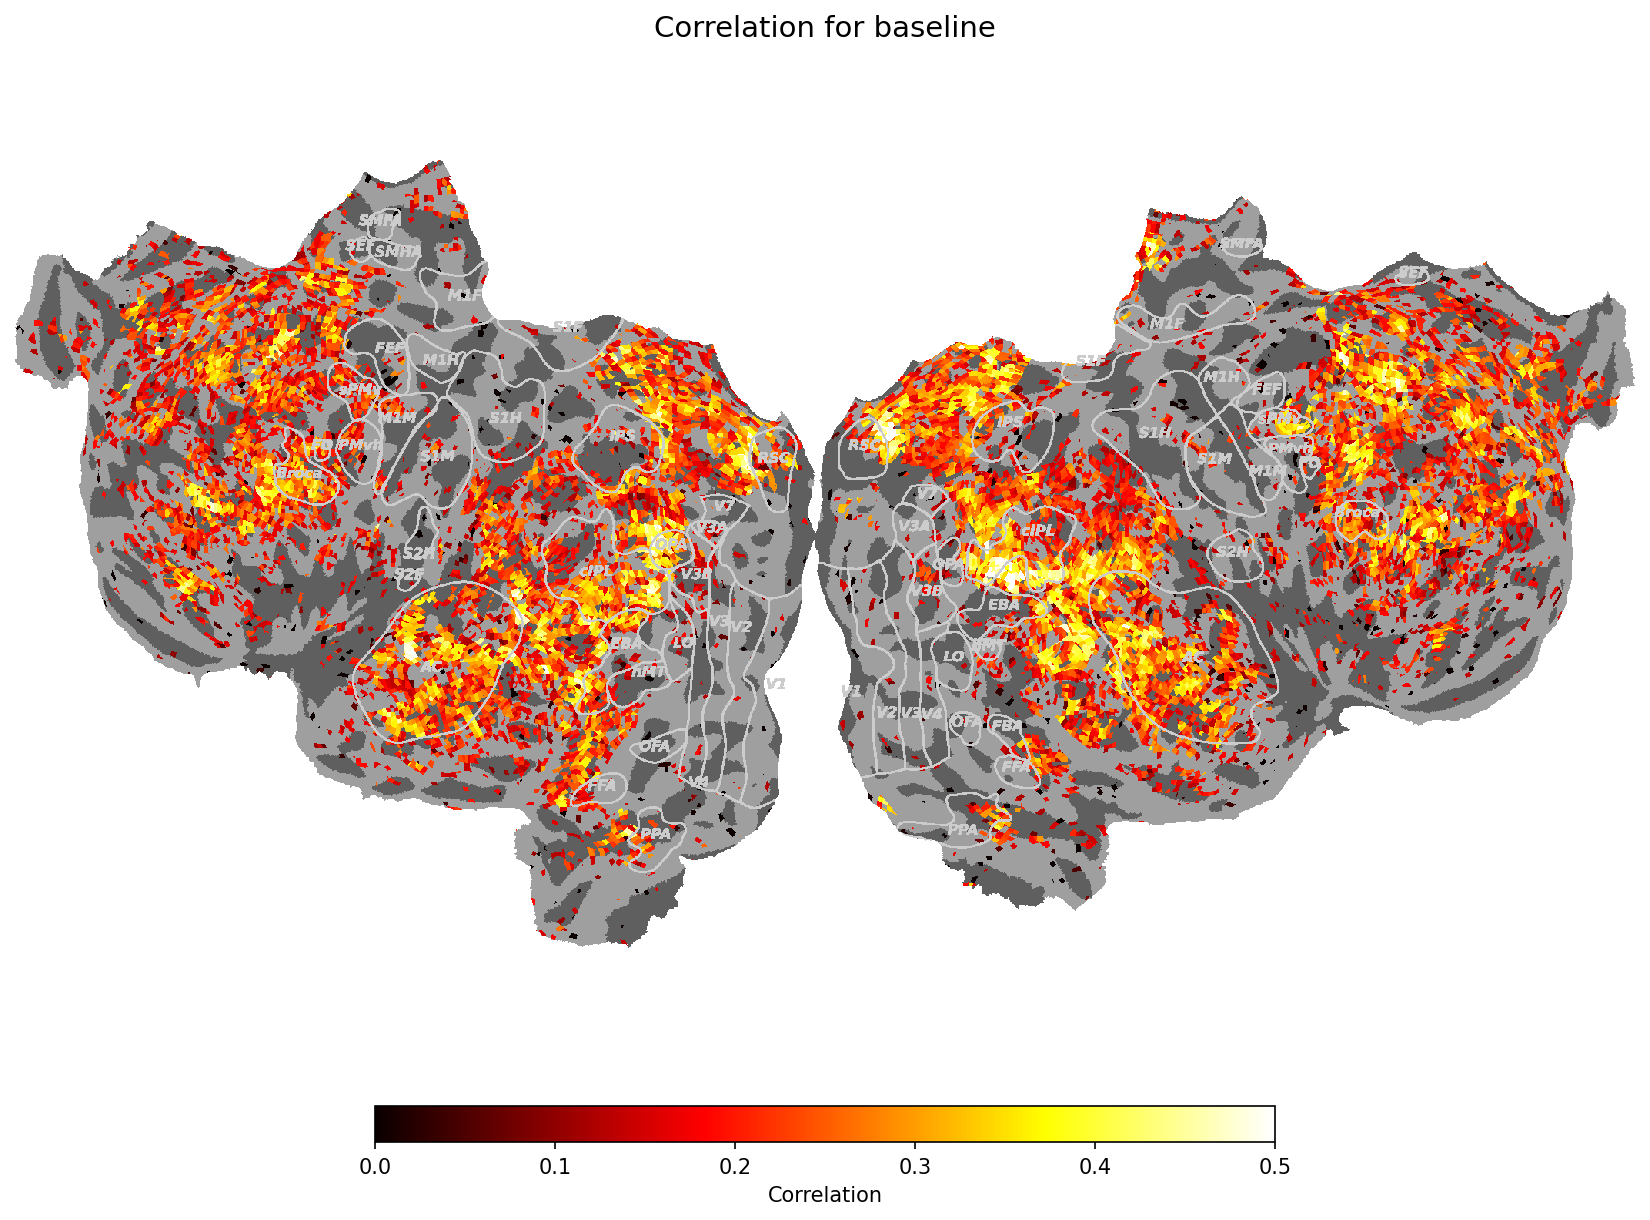

In [78]:
plotter.config.output_dir = root_dir/config.IMAGES_DIR/modality/subject/'heat'
_ = plotter.plot(
    data = [get_significant_voxels(results, 'baseline')],
    strategy = SingleCorrelationStrategy(vmax=0.5),
    title = f"Correlation for baseline",
    output_filename = 'baseline_correlation'
)

In [74]:
for mode in modes:
    _ = plotter.plot(
        data = [get_significant_voxels(results, mode)],
        strategy = SingleCorrelationStrategy(vmax=0.5),
        title = title.format(
            title=f"Correlation for {mode}", 
            subject=subject, 
            modality=modality
        ),
        output_filename=mode,
    )

Saved to ../outputs/images/listening/subject07/heat/baseline
Saved to ../outputs/images/listening/subject07/heat/english1000
Saved to ../outputs/images/listening/subject07/heat/zero
Saved to ../outputs/images/listening/subject07/heat/random
Saved to ../outputs/images/listening/subject07/heat/shuffle
Saved to ../outputs/images/listening/subject07/heat/remove-pos-noun
Saved to ../outputs/images/listening/subject07/heat/remove-pos-verb
Saved to ../outputs/images/listening/subject07/heat/remove-pos-adj
Saved to ../outputs/images/listening/subject07/heat/remove-pos-adv
Saved to ../outputs/images/listening/subject07/heat/remove-pos-pron
Saved to ../outputs/images/listening/subject07/heat/remove-pos-intj
Saved to ../outputs/images/listening/subject07/heat/remove-peaks
Saved to ../outputs/images/listening/subject07/heat/remove-valleys


## Plot Results Bivariate

In [113]:
subject = 'subject07'
modality = 'listening'
plotter.config.output_dir = root_dir/config.IMAGES_DIR/modality/subject/'bivariate'
plotter.config.smooth = False

In [75]:
results = file_io.load_results(
    root_dir / config.OUTPUT_DIR / "results",
    modality,
    subject
)

correlation_baseline = get_significant_voxels(results, 'baseline')

In [114]:
from plotting_utils import BivariateStrategy
for mode in modes:
    correlation_comparison = get_significant_voxels(results, mode)
    _ = plotter.plot(
        data = [correlation_baseline, correlation_comparison],
        strategy = BivariateStrategy(labels=['baseline', mode], vmax=0.4),
        title = title.format(
            title=title.format(
                title=f"Correlation Comparison: Baseline vs {mode}",
                subject=subject,
                modality=modality
            ), 
            subject=subject, 
            modality=modality
        ),
        output_filename = mode
    )

/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/scripts/plotting_utils.py:523: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


Saved to ../outputs/images/listening/subject07/bivariate/english1000
Saved to ../outputs/images/listening/subject07/bivariate/zero
Saved to ../outputs/images/listening/subject07/bivariate/random
Saved to ../outputs/images/listening/subject07/bivariate/shuffle
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-noun
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-verb
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-adj
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-adv
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-pron
Saved to ../outputs/images/listening/subject07/bivariate/remove-pos-intj
Saved to ../outputs/images/listening/subject07/bivariate/remove-peaks
Saved to ../outputs/images/listening/subject07/bivariate/remove-valleys


## Plot Results Colored

In [126]:
subject = 'subject07'
modality = 'reading'
modes = ['remove-pos-noun', 'remove-pos-verb', 'remove-pos-adj', 'remove-pos-adv', 'remove-pos-pron', 'remove-pos-intj']
control = ['remove-pos-pct-noun', 'remove-pos-pct-verb', 'remove-pos-pct-adj', 'remove-pos-pct-adv', 'remove-pos-pct-pron', 'remove-pos-pct-intj']
names = ['no-noun', 'no-verb', 'no-adj', 'no-adv', 'no-pron', 'no-intj']

results = file_io.load_results(
    root_dir / config.OUTPUT_DIR / "results",
    modality,
    subject
)

plotter.config.output_dir = root_dir/config.IMAGES_DIR/modality/subject/'colored'

In [127]:
e = 0.5
baseline = get_significant_voxels(results, 'baseline')
pos_actual = [get_significant_voxels(results, mode) for mode in modes]
# pos_control = [get_significant_voxels(results, mode for mode in control]

In [128]:
data_actual = np.vstack((pos_actual[:], baseline))
#data_control = np.vstack((pos_control[:4], baseline))
names_ = names[:]

Saved to ../outputs/images/reading/subject07/colored/worst


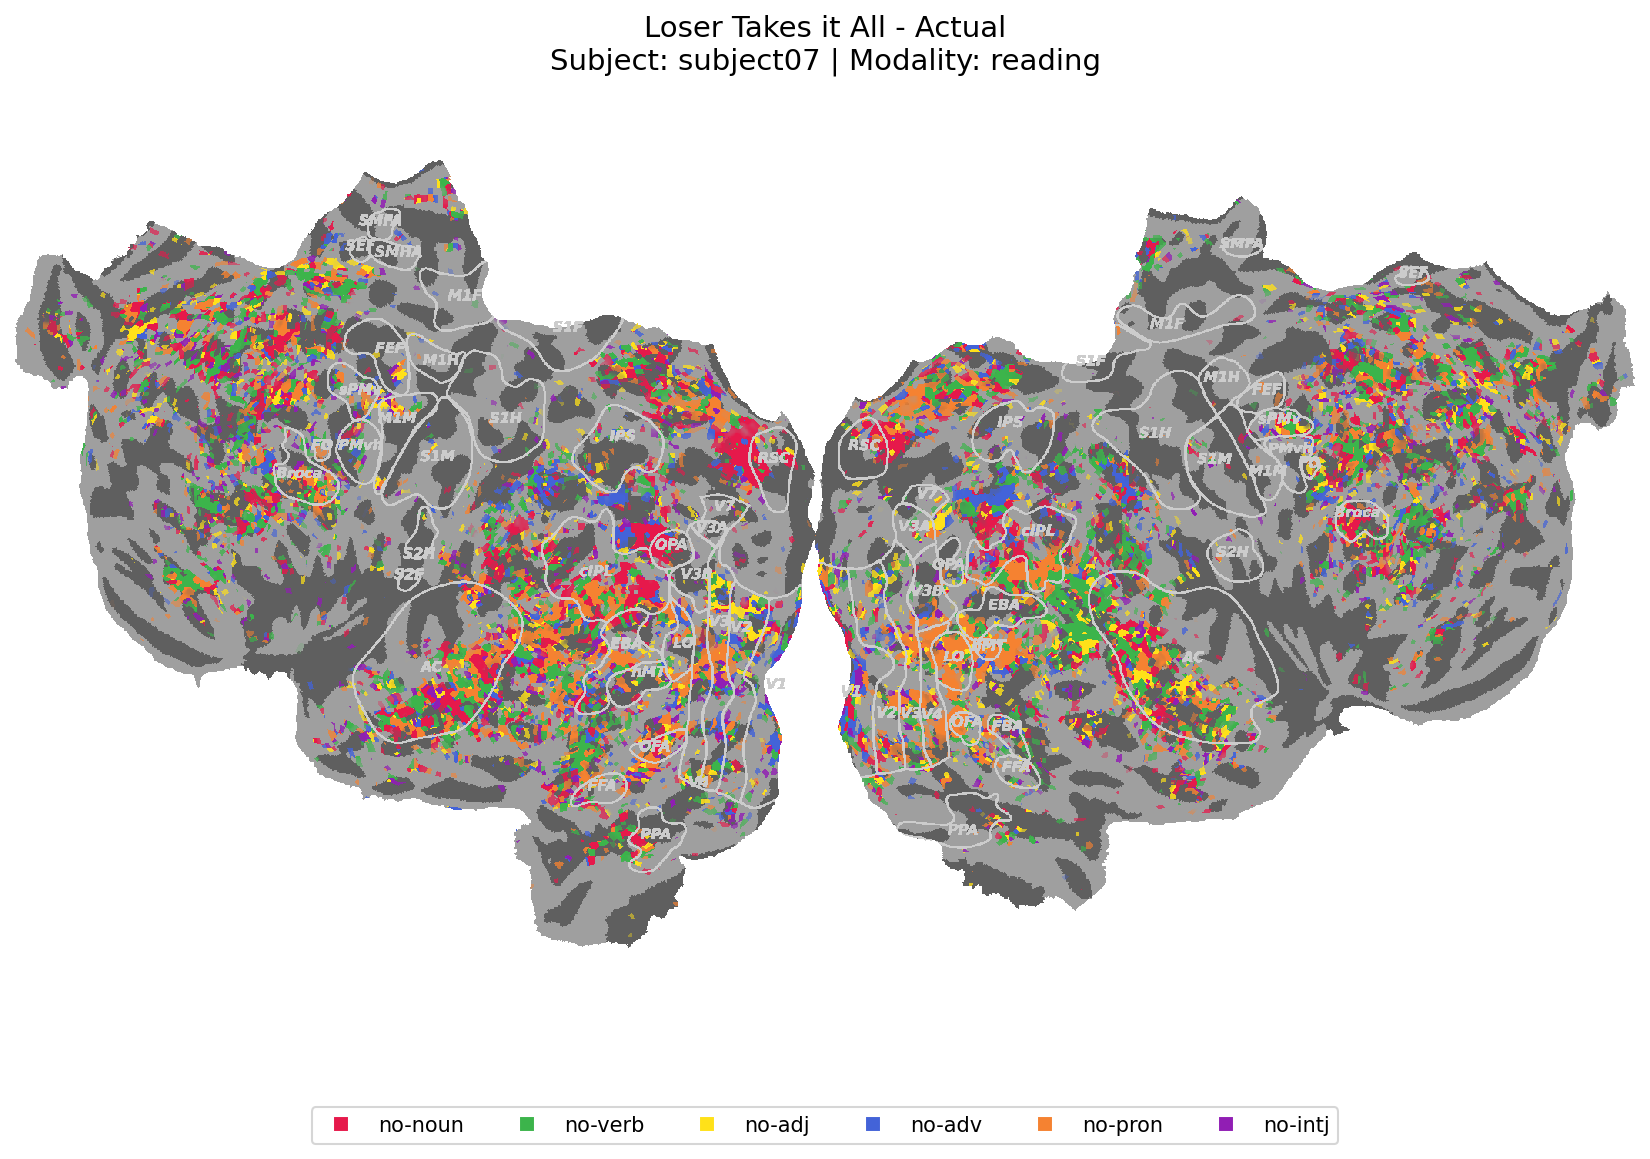

In [135]:
plotter.config.show = True
from plotting_utils import LoserTakesItAllStrategy
_ = plotter.plot(
    data = data_actual,
    strategy = LoserTakesItAllStrategy(names=names_, vmax=0.5),
    title = title.format(title = "Loser Takes it All - Actual", subject=subject, modality=modality),
    output_filename = 'worst'
)
# _ = plotter.plot(
#     data = data_control,
#     strategy = LoserTakesItAllStrategy(names=names_, vmax=0.4),
#     title = title.format(title = "Loser Takes it All - Control", subject=subject, modality=modality),
#     output_filename = 'control'
# )

Saved to ../outputs/images/reading/subject07/colored/margin-actual


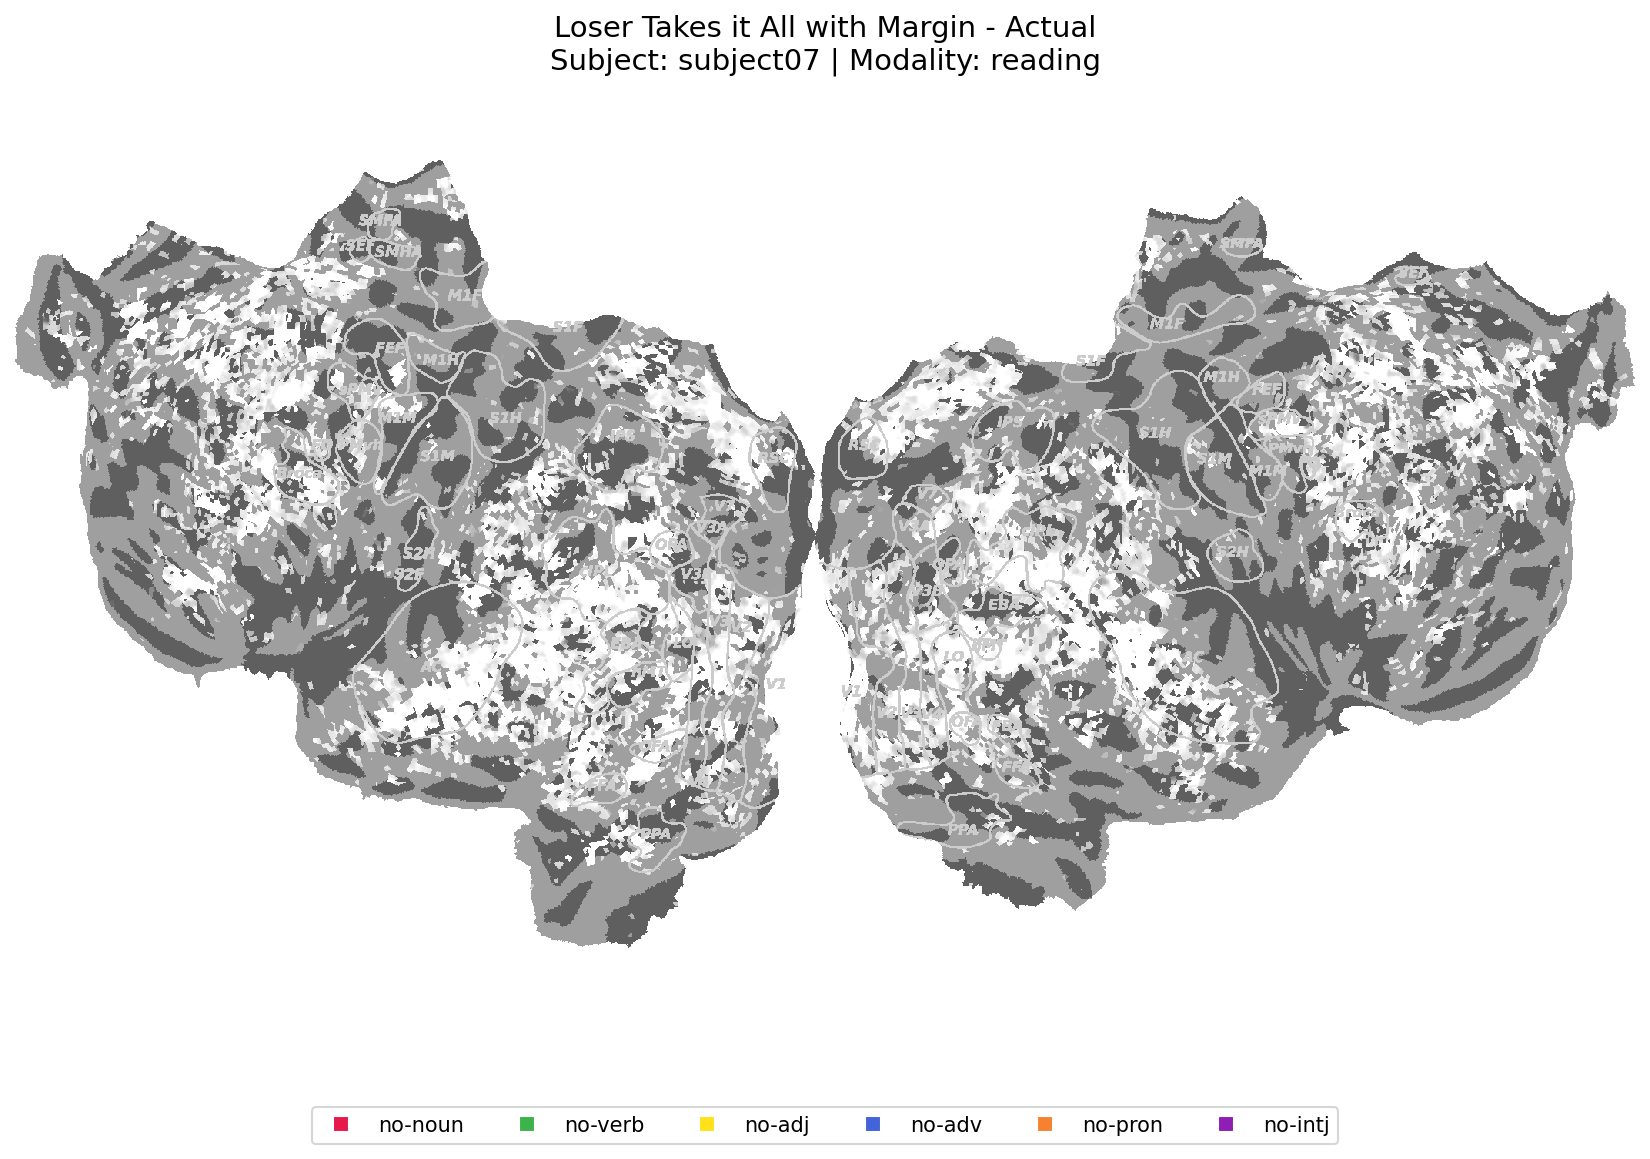

In [132]:
from plotting_utils import LoserTakesItAllMarginStrategy
_ = plotter.plot(
    data = data_actual,
    strategy = LoserTakesItAllMarginStrategy(names=names, vmax=0.5),
    title = title.format(title = "Loser Takes it All with Margin - Actual", subject=subject, modality=modality),
    output_filename = f'margin-actual'
)

# _ = plotter.plot(
#     data = data_control,
#     strategy = LoserTakesItAllMarginStrategy(names=names, vmax=0.4),
#     title = title.format(title = "Loser Takes it All with Margin - Control", subject=subject, modality=modality),
#     output_filename = f'margin-control'
# )

In [84]:
stacked_actual = np.stack(pos_actual, axis=0)-baseline
loser_indices = np.argsort(stacked_actual, axis=0)[0]
second_loser_indices = np.argsort(stacked_actual, axis=0)[1]
idx = np.indices(stacked_actual.shape[1:])
margins_actual = stacked_actual[second_loser_indices, idx] - stacked_actual[loser_indices, idx]
drops_actual = stacked_actual[loser_indices, idx]

stacked_control = np.stack(pos_control, axis=0)-baseline
loser_indices = np.argsort(stacked_control, axis=0)[0]
second_loser_indices = np.argsort(stacked_control, axis=0)[1]
idx = np.indices(stacked_control.shape[1:])
margins_control = stacked_control[second_loser_indices, idx] - stacked_control[loser_indices, idx]
drops_control = stacked_control[loser_indices, idx]

df = pd.DataFrame({
    'margins_actual': margins_actual.flatten(),
    'margins_control': margins_control.flatten(),
    'drops_actual': drops_actual.flatten(),
    'drops_control': drops_control.flatten(),
})

In [102]:
np.nanmean(pos_actual[0]-baseline)

np.float32(-0.009475965)

In [112]:
Z = (df['drops_actual']-df['drops_control'].mean())/df['drops_control'].std()

<Axes: xlabel='drops_actual', ylabel='Density'>

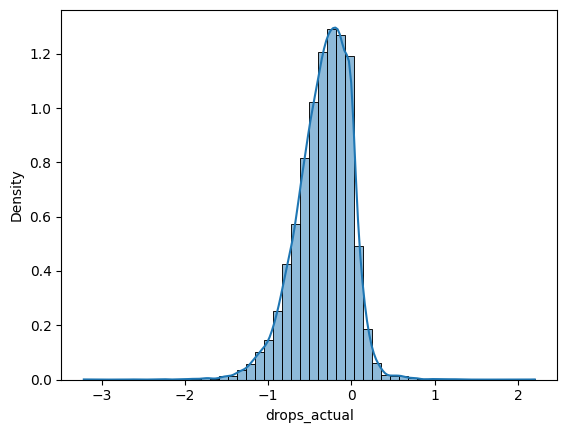

In [115]:
sns.histplot(Z, kde=True, stat="density", bins=50)

<Axes: ylabel='Density'>

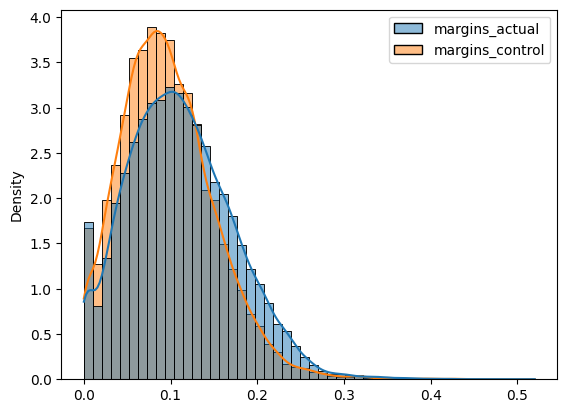

In [25]:
sns.histplot(np.sqrt(df[['margins_actual', 'margins_control']]), color='blue', label='Control', kde=True, stat="density", bins=50)

In [ ]:
print(np.nanmean(correlations_sig, axis=1))
print(np.nanmean(control_correlations_sig, axis=1))


[-0.01412276 -0.00393522  0.00345566  0.01209748  0.00215703  0.01366676]
[ 0.00531451  0.00439657  0.00338359  0.0052715  -0.00653938  0.00766664]


Saved to ../outputs/images/POS/subject07_listening_loser_margin.png


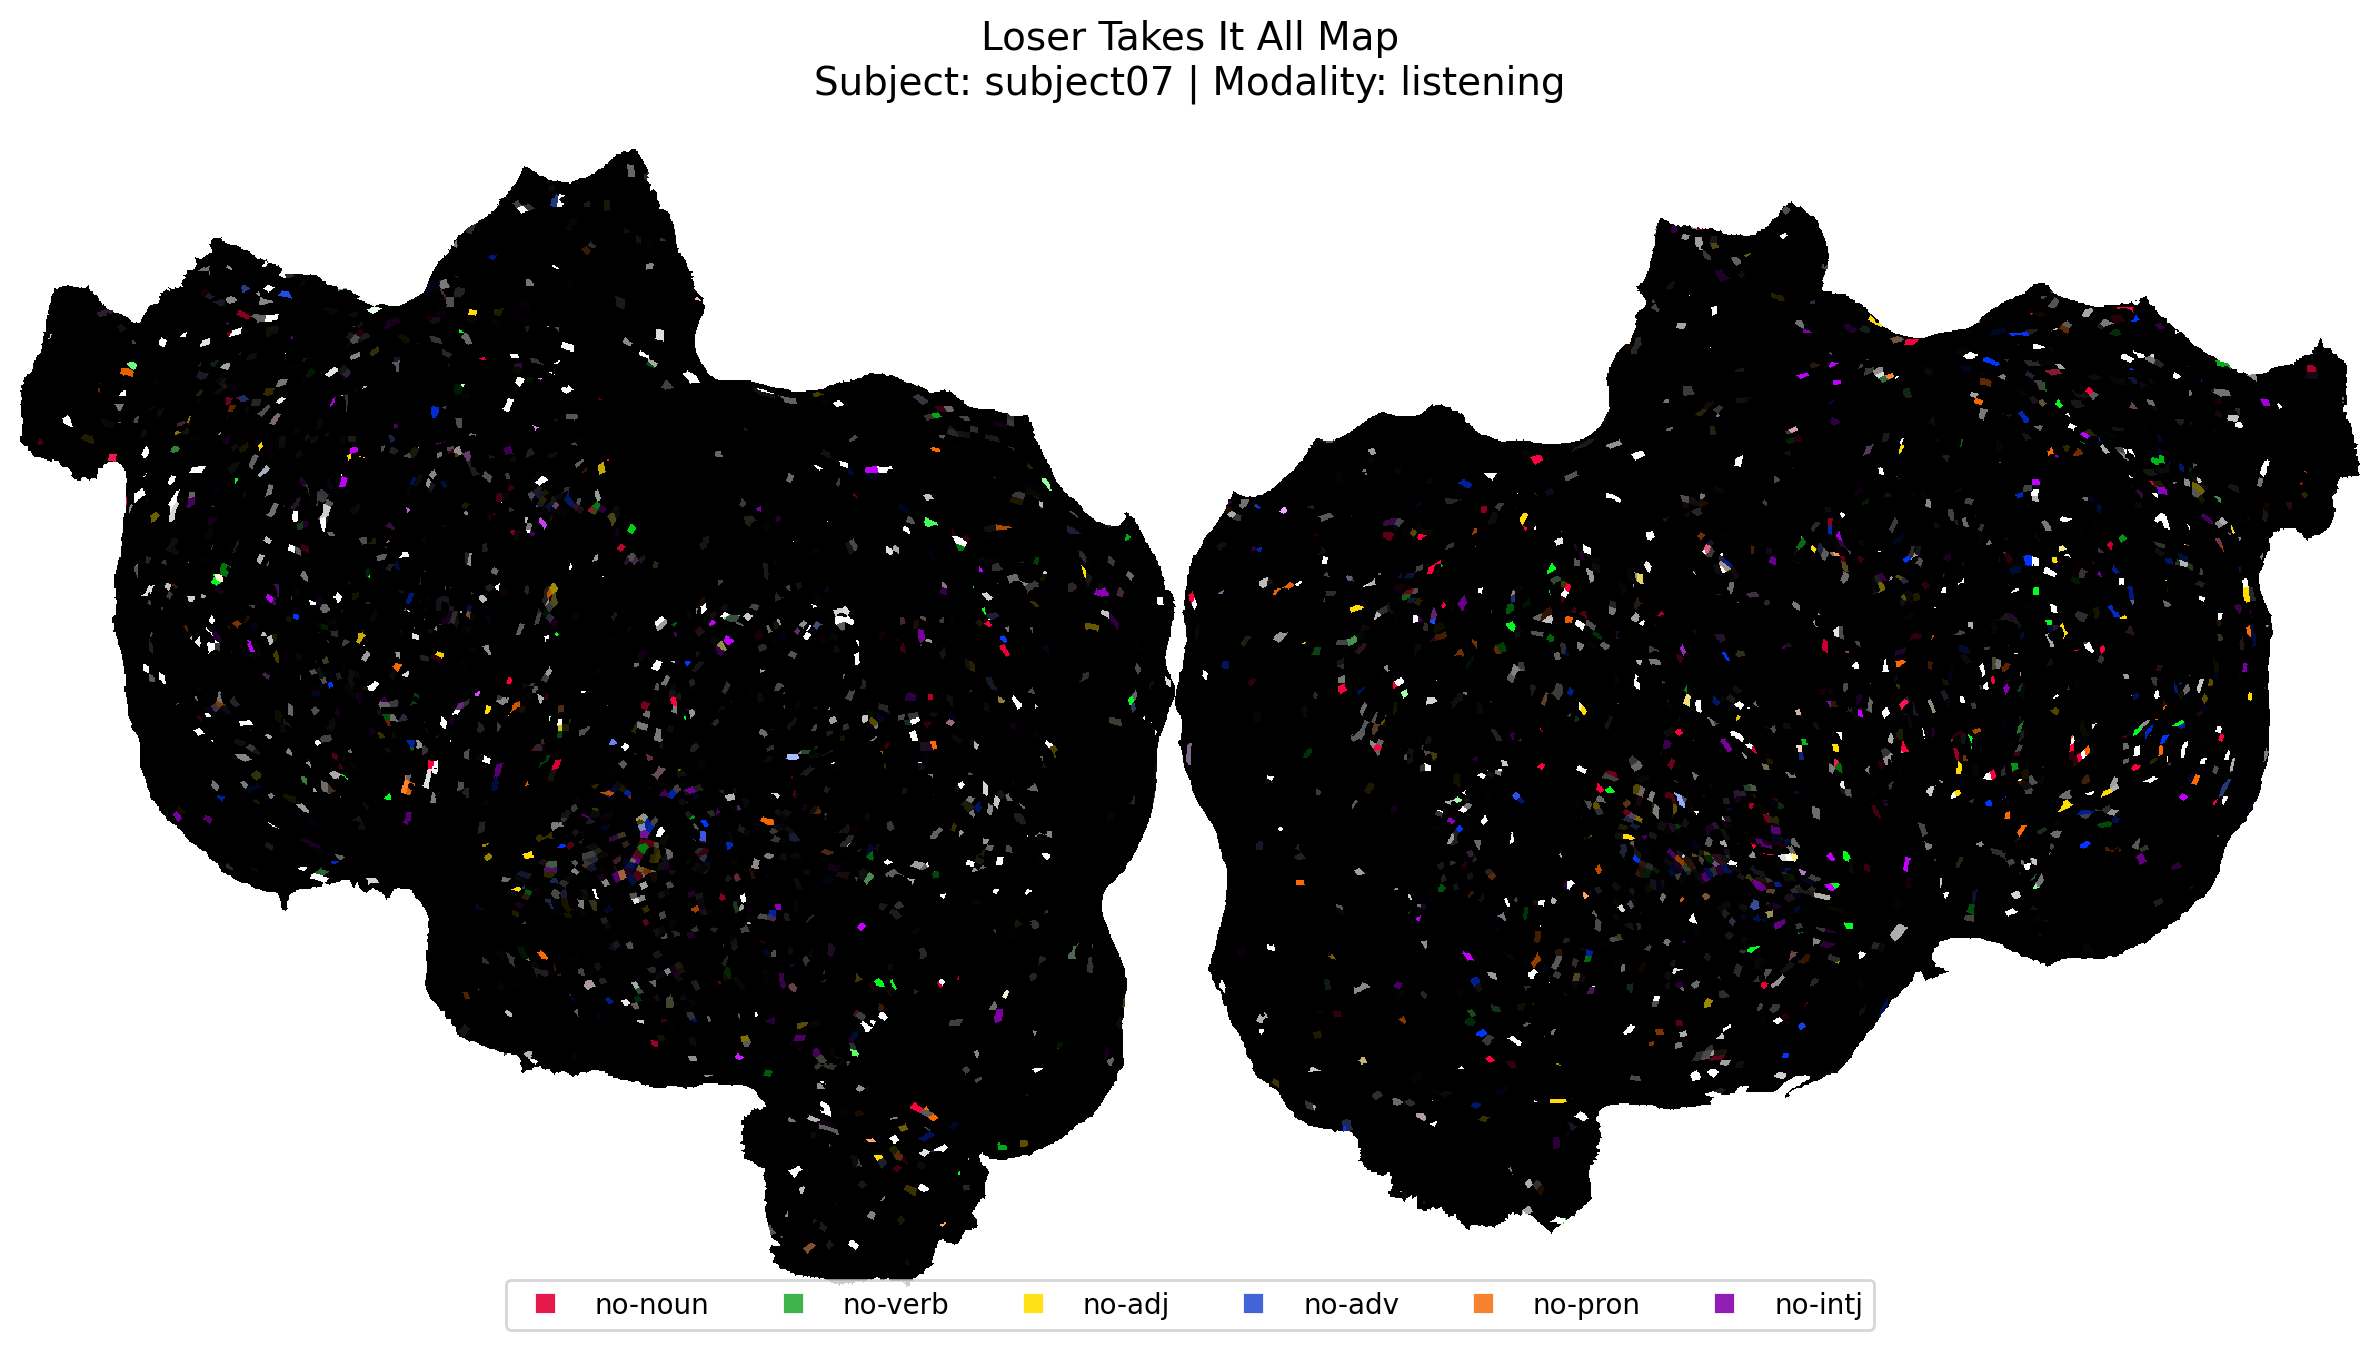

In [89]:
pu.plot_loser_takes_it_all_margin(
    subject,
    modality,
    control_correlations_sig[:],
    names[:],
    root_dir/config.MAPPER_PATH,
    root_dir/config.IMAGES_DIR/'POS',
    regions = False,
    show = True,
)

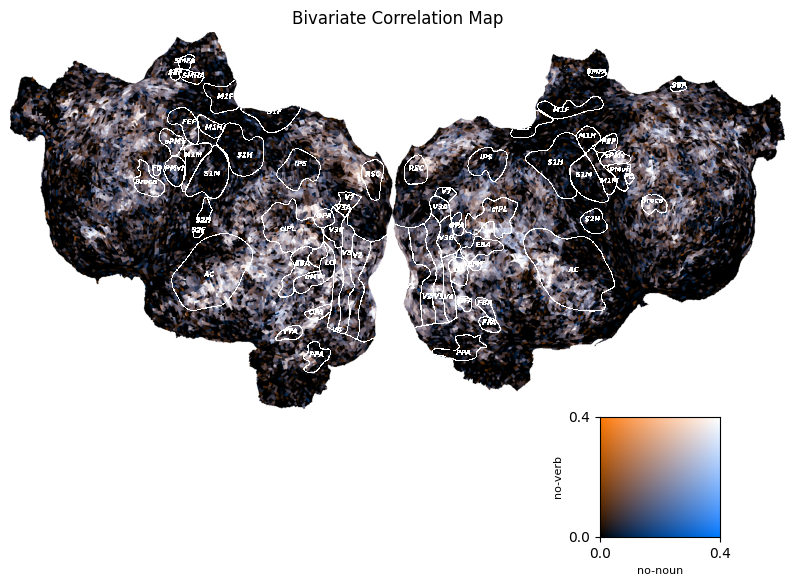

In [57]:
pu.plot_bivariate_flatmap(
    subject,
    modality,
    correlations[0],
    correlations[1],
    names[0],
    names[1],
    root_dir/config.MAPPER_PATH,
    root_dir/config.IMAGES_DIR/'bivariate',
    show = True
)

/var/folders/np/4_877nsn33dg2fxw67bzsw2r0000gn/T/ipykernel_28047/3923566931.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Condition', y='Margin', data=df,


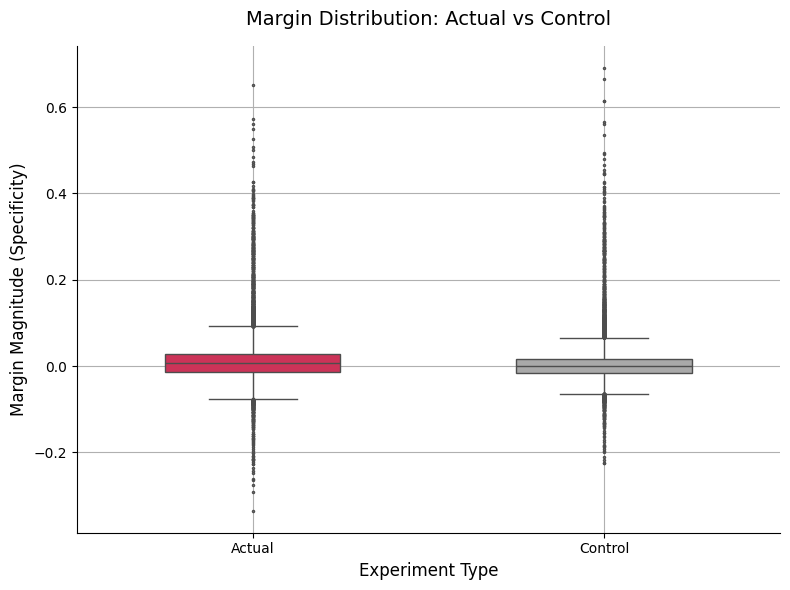

In [196]:
plot_margin_comparison(correlations_sig[3], control_correlations_sig[3])

In [40]:
def compute_margin(corr):
    stacked = np.stack(corr, axis=0)
    worst_indices = np.argsort(stacked, axis=0)[0]
    second_worst_indices = np.argsort(stacked, axis=0)[1]

    worst_vals = stacked[worst_indices, np.arange(stacked.shape[1])]
    second_worst_vals = stacked[second_worst_indices, np.arange(stacked.shape[1])]

    margin = second_worst_vals- worst_vals
    return margin

In [194]:
def plot_margin_comparison(margins_actual, margins_control, title="Margin Distribution: Actual vs Control"):
    # 1. Flatten and Clean Data (Remove NaNs and Zeros)
    actual_clean = margins_actual.flatten()[~np.isnan(margins_actual.flatten()) & (margins_actual.flatten() != 0)]
    control_clean = margins_control.flatten()[~np.isnan(margins_control.flatten()) & (margins_control.flatten() != 0)]

    # 2. Create a Long-form DataFrame (Required for Seaborn)
    df_actual = pd.DataFrame({'Margin': actual_clean, 'Condition': 'Actual'})
    df_control = pd.DataFrame({'Margin': control_clean, 'Condition': 'Control'})
    df = pd.concat([df_actual, df_control])

    # 3. Plotting
    plt.figure(figsize=(8, 6))
    
    # We use a boxplot to show the quartiles
    # fliersize=1 makes the outlier dots small so they don't overwhelm the plot
    ax = sns.boxplot(x='Condition', y='Margin', data=df, 
                     palette={'Actual': '#E6194B', 'Control': '#A9A9A9'},
                     fliersize=1.5, width=0.5)

    # Optional: Add a 'notch' to show the confidence interval around the median
    # sns.boxplot(..., notch=True)

    plt.title(title, fontsize=14, pad=15)
    plt.ylabel("Margin Magnitude (Specificity)", fontsize=12)
    plt.xlabel("Experiment Type", fontsize=12)
    plt.grid()
    sns.despine() # Makes the plot look cleaner for a thesis
    plt.tight_layout()
    plt.show()

In [93]:
margins_actual.shape

(92970,)

/tmp/ipykernel_756224/3529872632.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Condition', y='Margin', data=df,


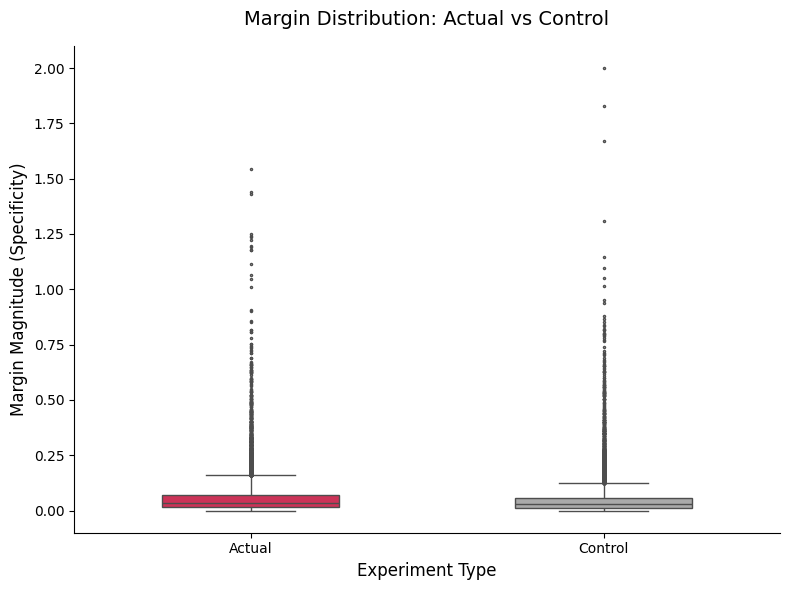

In [84]:
margins_actual = compute_margin(correlations_sig)
margins_control = compute_margin(control_correlations_sig)
plot_margin_comparison(margins_actual, margins_control)

In [83]:
diff = margins_actual - margins_control
print(f"Margin Difference: Mean={np.nanmean(diff):.4f}, Median={np.nanmedian(diff):.4f}, Std={np.nanstd(diff):.4f}")
v_max = np.nanpercentile(np.abs(diff), 95)
normalized = diff / (v_max + 1e-10)
diff_normal = np.clip(normalized, -1, 1)

Margin Difference: Mean=0.0109, Median=0.0056, Std=0.0790


Saving flatmap figure to /mnt/antares_raid/home/simonee/nonsense/outputs/images/margin_diff/subject07_listening_drop_verb.png


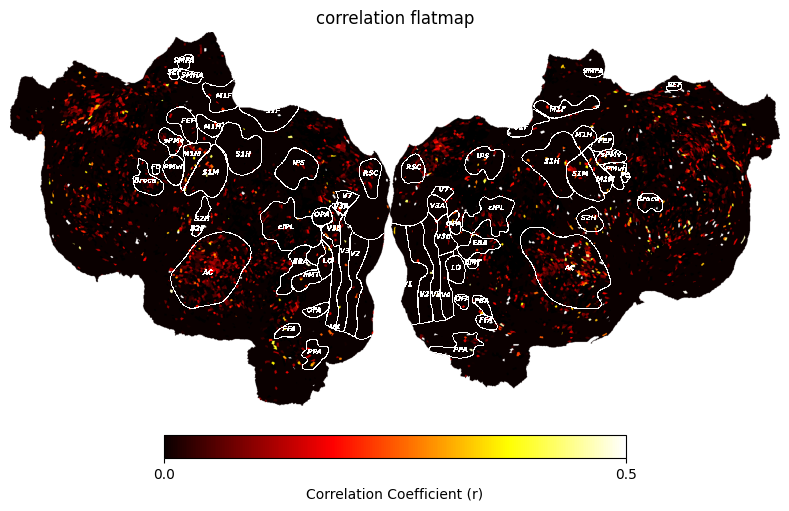

In [ ]:
pu.plot_correlation_on_flatmap(
    subject,
    modality,
    "drop_control",
    contro,
    root_dir/config.MAPPER_PATH,
    root_dir/config.OUTPUT_DIR/"images"/"margin_diff",
    show = True,
    regions=True
)

Saving flatmap figure to /mnt/antares_raid/home/simonee/nonsense/outputs/images/margin_diff/subject07_listening_diff_normal.png


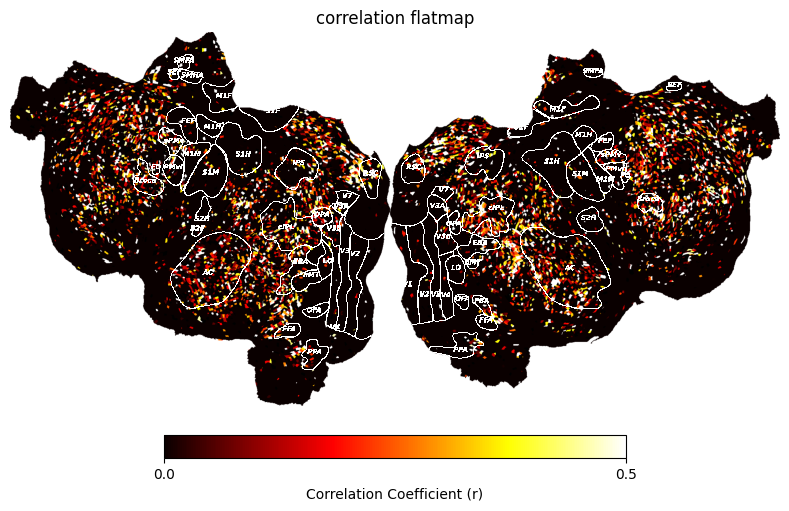

In [82]:
pu.plot_correlation_on_flatmap(
    subject,
    modality,
    "diff_normal",
    diff_normal,
    root_dir/config.MAPPER_PATH,
    root_dir/config.OUTPUT_DIR/"images"/"margin_diff",
    show = True,
    regions=True
)

## Story Analysis

In [136]:
import spacy
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_pos(text, pos_tags):
    """Analyze parts of speech in text and return percentages."""
    doc = nlp(text)
    pos_counts = defaultdict(int)
    
    for token in doc:
        if token.pos_ in pos_tags:
            pos_counts[token.pos_] += 1
    
    total = sum(pos_counts.values())
    
    percentages = {tag: (pos_counts[tag] / total * 100) if total > 0 else 0 for tag in pos_tags}
    
    return percentages


In [137]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Sample stories (replace with your actual data)
stories = file_io.load_dataseqs(root_dir / config.DATASEQ_PATH, config.STORIES)
stories = {'story ' + str(i): ' '.join(v.data) for i, v in enumerate(stories.values())}

OSError: [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

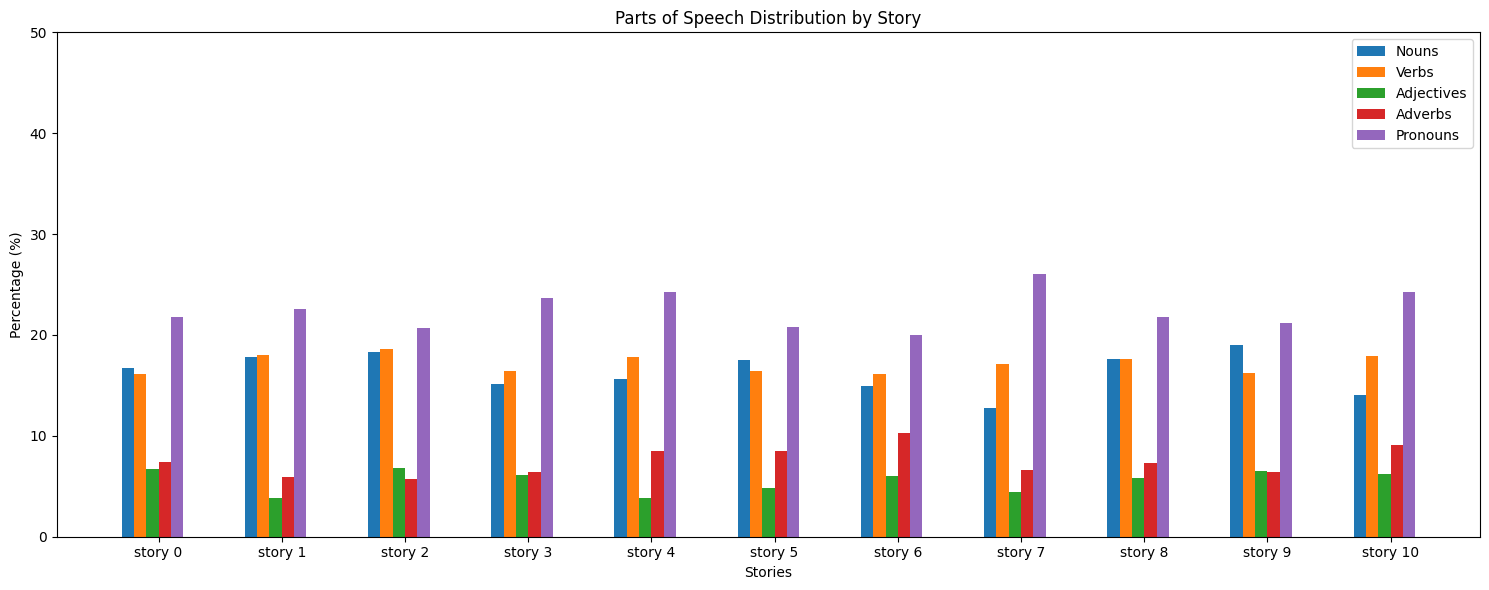

In [86]:
# Analyze each story
pos = {}
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ', 'PROPN', 'ADP', 'CONJ', 'DET', 'NUM', 'PART', 'SCONJ', 'PUNCT', 'SYM', 'X']
for story_name, text in stories.items():
    pos[story_name] = analyze_pos(text, pos_tags)

# Prepare data for plotting
story_names = list(pos.keys())
nouns = [pos[s]["NOUN"] for s in story_names]
verbs = [pos[s]["VERB"] for s in story_names]
adjectives = [pos[s]["ADJ"] for s in story_names]
adverbs = [pos[s]["ADV"] for s in story_names]
pronouns = [pos[s]["PRON"] for s in story_names]
interjections = [pos[s]["INTJ"] for s in story_names]
proper_nouns = [pos[s]["PROPN"] for s in story_names]
adpositions = [pos[s]["ADP"] for s in story_names]
conjunctions = [pos[s]["CONJ"] for s in story_names]
determiners = [pos[s]["DET"] for s in story_names]
numerals = [pos[s]["NUM"] for s in story_names]
particles = [pos[s]["PART"] for s in story_names]
subordinating_conjunctions = [pos[s]["SCONJ"] for s in story_names]
punctuations = [pos[s]["PUNCT"] for s in story_names]
symbols = [pos[s]["SYM"] for s in story_names]
others = [pos[s]["X"] for s in story_names]

# Create bar chart
x = range(len(story_names))
width = 0.1

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar([i - 2.5*width for i in x], nouns, width, label="Nouns")
ax.bar([i - 1.5*width for i in x], verbs, width, label="Verbs")
ax.bar([i - 0.5*width for i in x], adjectives, width, label="Adjectives")
ax.bar([i + 0.5*width for i in x], adverbs, width, label="Adverbs")
ax.bar([i + 1.5*width for i in x], pronouns, width, label="Pronouns")
ax.set_xlabel("Stories")
ax.set_ylabel("Percentage (%)")
ax.set_title("Parts of Speech Distribution by Story")
ax.set_xticks(x)
ax.set_xticklabels(story_names)
ax.legend()
ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()


In [140]:
import warnings
import numpy as np

def get_loser_counts(correlations, names):
    stacked = np.stack(correlations, axis=0)

    # Identify all-NaN columns before calling nanargmin
    all_nan_mask = np.all(np.isnan(stacked), axis=0)

    # Replace all-NaN columns with a safe value (e.g., infinity)
    stacked_safe = stacked.copy()
    stacked_safe[:, all_nan_mask] = np.inf

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        loser_indices = np.nanargmin(stacked_safe, axis=0)

    # Mark all-NaN positions with -1 (or np.nan)
    loser_indices[all_nan_mask] = -1

    # Count occurrences for each condition
    counts = np.bincount(loser_indices[loser_indices >= 0].astype(int), minlength=len(names))

    # turn counts into percentages
    counts = counts / np.sum(counts) * 100
    return counts

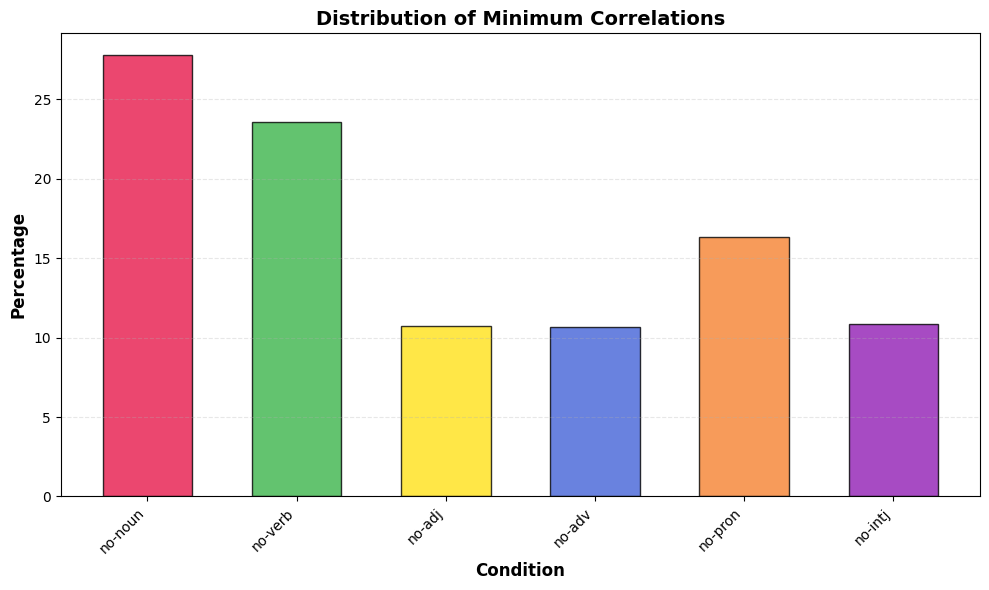

In [141]:
# Create bar chart with color coding
counts = get_loser_counts(correlations_sig, names)
x = np.arange(len(names))
width = 0.6

colors = ["#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231", "#911EB4"] 

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, counts, width=width, color=colors, edgecolor='black', alpha=0.8)

ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Minimum Correlations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

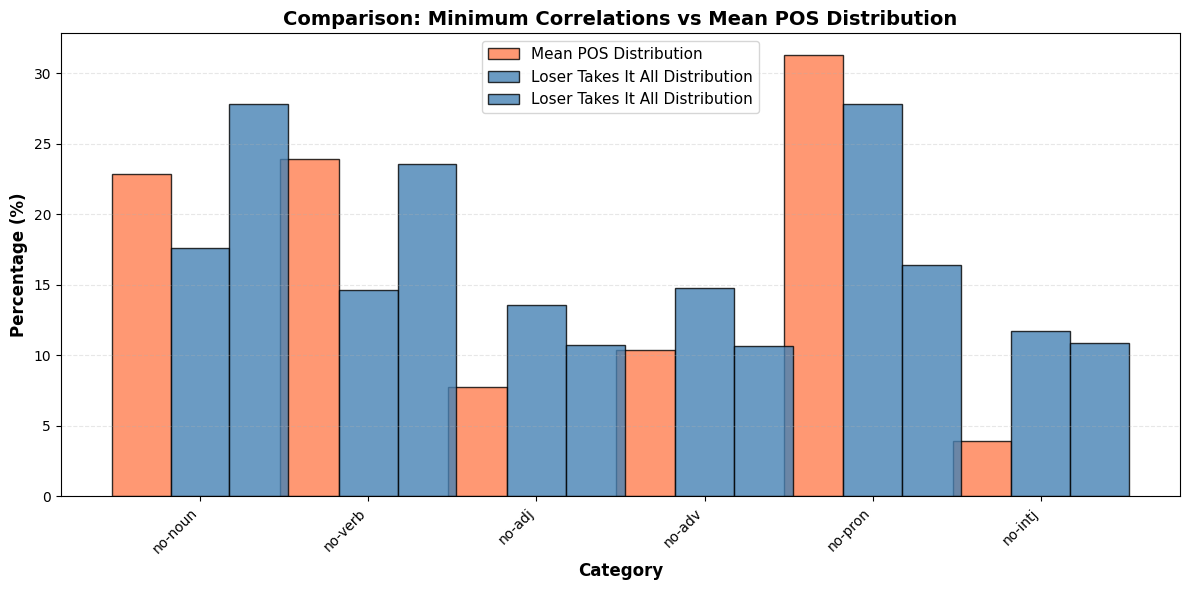

In [ ]:
# Prepare POS frequency data for comparison
pos = {}
pos_labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
for story_name, text in stories.items():
    pos[story_name] = analyze_pos(text, pos_labels)
pos_mean = np.array([list(v.values()) for v in pos.values()]).mean(axis=0)

# Prepare control correlations for comparison
control_counts = get_loser_counts(control_correlations_sig, names)

# Prepare data for comparison
pos_mean_values = pos_mean 

# Create side-by-side bar plot
x = np.arange(len(names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Plot POS frequency values
ax.bar(x - width, pos_mean_values, width, label='Mean POS Distribution', 
       color='coral', edgecolor='black', alpha=0.8)

# Plot control counts (from loser_indices analysis)
ax.bar(x, control_counts, width, label='Loser Takes It All Distribution', 
       color='', edgecolor='black', alpha=0.8)

# Plot actual counts (from loser_indices analysis)
ax.bar(x + width, counts, width, label='Loser Takes It All Distribution', 
       color='steelblue', edgecolor='black', alpha=0.8)


ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparison: Minimum Correlations vs Mean POS Distribution', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [164]:
import h5py
with h5py.File(root_dir/config.MAPPER_PATH/'subject07_mappers.hdf') as hf:
    curvature = hf["flatmap_mask"][()]


In [167]:
curvature

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(2105, 1024))

## PEAKS VS VALLEYS

In [47]:
peaks_sig = get_significant_voxels(results, 'remove-peaks')
valleys_sig = get_significant_voxels(results, 'remove-valleys')

In [54]:
plotter.config.output_dir = root_dir/config.IMAGES_DIR/modality/subject/'peaks_valleys'
plotter.config.show = True
plotter.config.smooth = False

Saved to ../outputs/images/reading/subject07/colored/peaks_vs_valleys


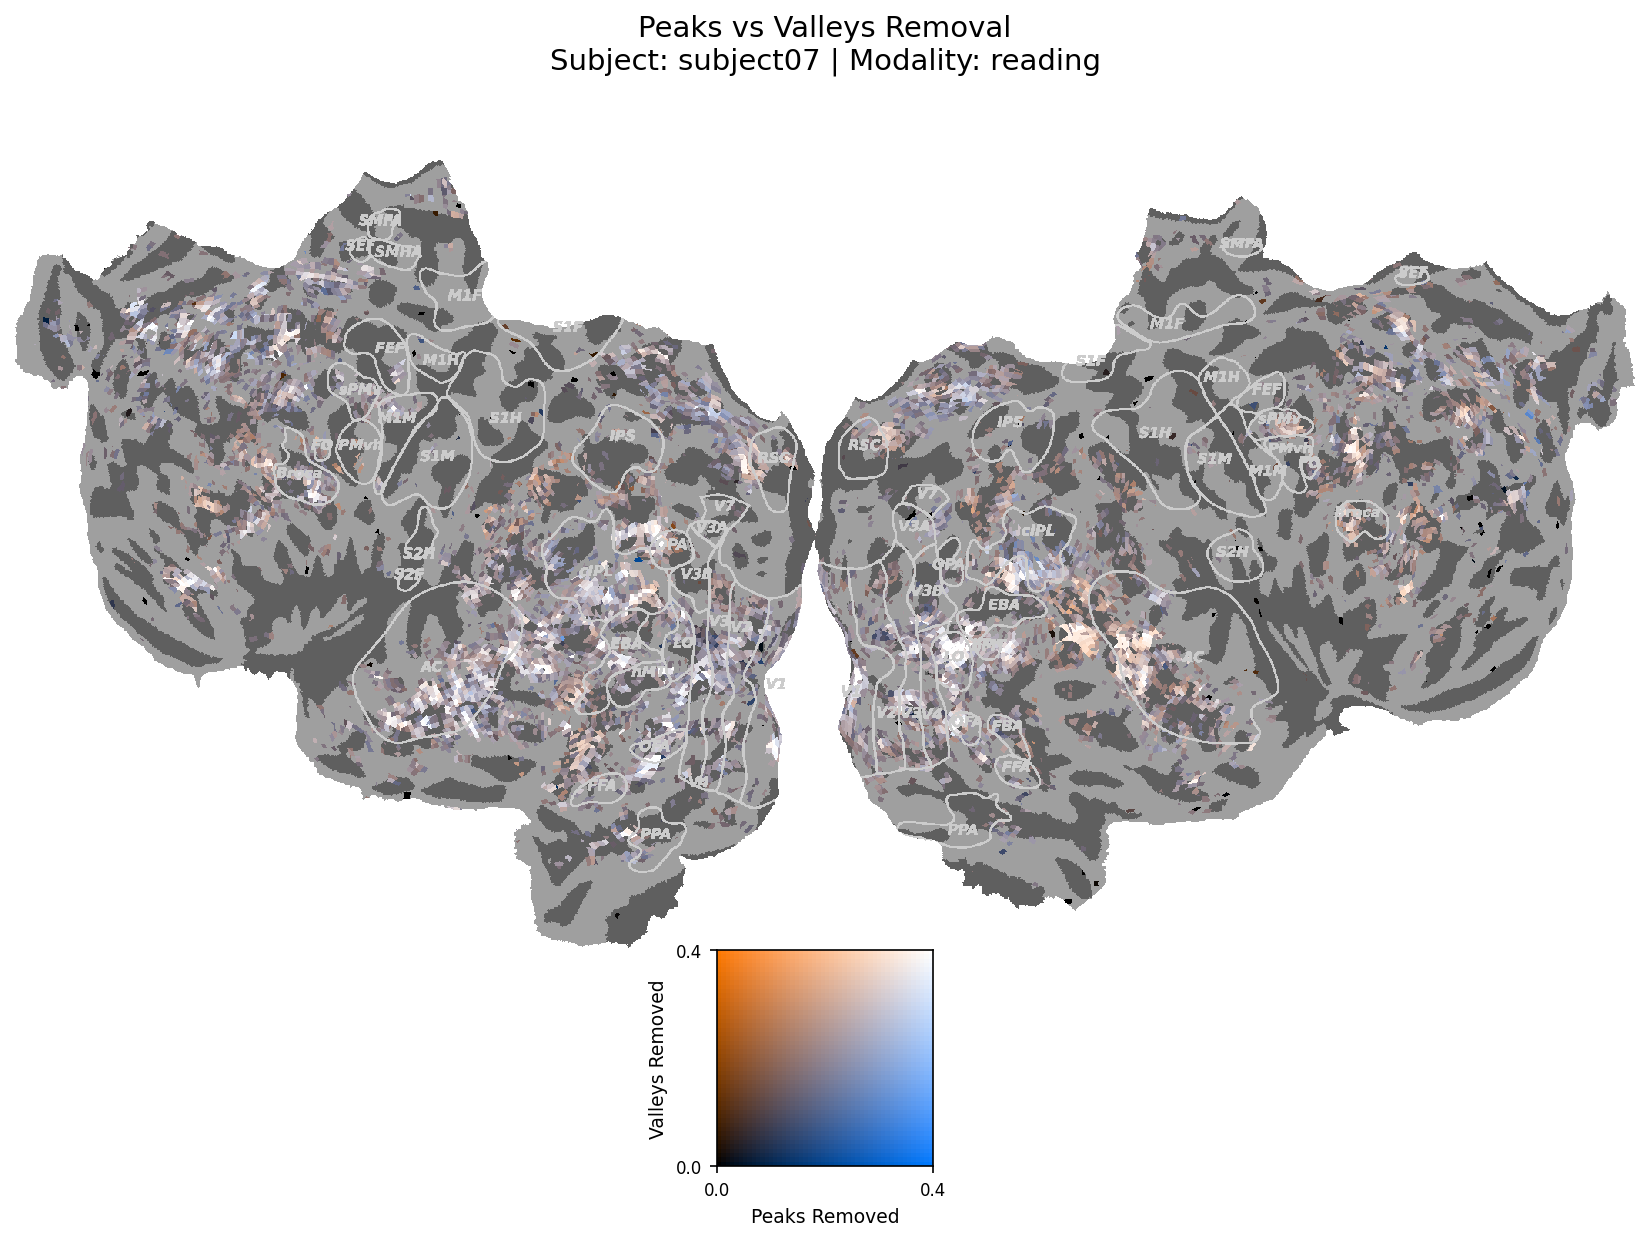

In [62]:
from plotting_utils import BivariateStrategy
_ = plotter.plot(
    data = [peaks_sig, valleys_sig],
    strategy = BivariateStrategy(labels=['Peaks Removed', 'Valleys Removed'], vmax=0.4),
    title = title.format(title=f"Peaks vs Valleys Removal", subject=subject, modality=modality),
    output_filename = 'peaks_vs_valleys'
)